In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# matplotlib /
#     - user/ <- functions...
#     - main/ <- functions...
#     - pyplot/ <- functions...!!!

In [3]:
df = pd.read_csv("../data/netflix_titles.csv")
df.sample(3)

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3513,81172904,Seven and a half dates,Biodun Stephen,"Mercy Johnson, Jim Iyke, Toyin Abraham, Sola S...",NaN,"December 13, 2019",2018,TV-14,107 min,"Dramas, International Movies, Romantic Movies","Engrossed in her career, a young woman relucta..."
589,81168348,Jealousy and medicine,Janusz Majewski,"Mariusz Dmochowski, Ewa Krzyżewska, Włodzimier...",Poland,"October 1, 2019",1973,TV-MA,97 min,"Dramas, International Movies, Romantic Movies","Tormented by mistrust, a businessman hires a c..."
2010,80076698,Ip Man 3,Wilson Yip,"Donnie Yen, Zhang Jin, Lynn Hung, Patrick Tam,...","China, Hong Kong","June 18, 2016",2015,PG-13,105 min,"Action & Adventure, Dramas, International Movies",Martial arts master Ip springs into action whe...


Признаки:
1. числовой
    - непрерывные
    - дискретные
2. категориальные
    - номинальные 
    - ранговые
3. упорядоченные (картинки; текст; аудио; видео; ...)
4. время / дату

In [ ]:
#
df["release_year"].max()

2020

Для числовых признаков можно аггрегировать:
- `.max()` - максимальное значение
- `.min()` - минимальное значение
- `.mode()` - самое популярное
- `.mean()` - считает среднее арифметическое = сумма / количество
- `.median()` - медиана (центральное значение)
- `.sum()` - сумма значений
- `.count()` - количество НЕпропущенных значений
- `.quantile(0.25)` - первый квартиль (меньше него 25% данных)
- `.quantile(0.75)` - третий квартиль (меньше него 75% данных)

Для числовых - визуализация с помощью **гистограммы**

In [ ]:
df["duration_min"] = df["duration"].apply(lambda x: int(x.replace("min", "").strip()))

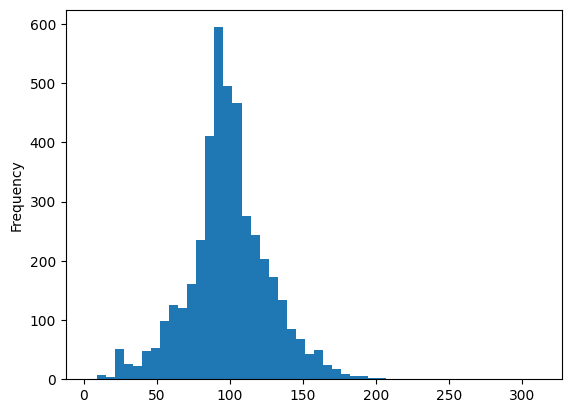

In [ ]:
df["duration_min"].plot(kind="hist", bins=50);

**Меры центральной тенденции**
- среднее (`mean()`) - не устойчиво к выбросам (экстремально высокие или низкие значения)
- медиана (`median()`) - устойчива к выбросам
- мода (`mode()`) - устойчива к выбросам

**Меры вариативности**
- дисперсия (`.var()`) / стандартное отклонение (`std()`) - не устойчиво к выбросам
- интерквартильный размах = `q3 - q1` - устойчиво к выбросам

---

1. `pie` = круговая
2. `bar` = столбчатая

In [ ]:
df["country"].value_counts().sort_values(ascending=False).head(10)

# по умолчанию сортирует категории по убыванию втсречаемости

# | категория | сколько строк с этой категорией |
# | USA       | 1200  |
# | Russia    | 800   |
# | ...       | ...   |

country
United States     1482
India              724
United Kingdom     170
Canada              88
Spain               80
Turkey              55
Mexico              54
France              50
Hong Kong           49
Japan               47
Name: count, dtype: int64

<Axes: ylabel='count'>

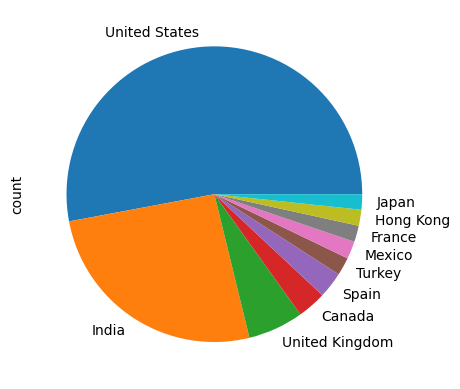

In [ ]:
df["country"].value_counts().head(10).plot(kind="pie")

**МЦТ**
- мода = (`.mode()`) - самая популярная категория (самая частотная)

**Мера вариантивности**
- количество уникальных значений (`.nunique()`)

In [ ]:
df["country"].mode()[0]

'United States'

In [ ]:
df["country"].nunique()

482

# **Line**

Линейный график - обычно строится как **времненой ряд**, который показывает изменение величины $x$ со временем. Например:
- как изменялось количество закзаов на сайте с 2010 года
- как изменялась цена биткоина
- количество выпущенных песен на спотифае

Какие должны быть данные:
- $OX$ - Дата / таймстемп (=дата + время)
- $OY$ - Для каждой даты - значение признака $x$ (должно быть одно!)

**NOTE**: даты должны быть упорядочены, когда строим график

In [15]:
# частотная таблица = .value_counts по КАТЕГОРИАЛЬНОМУ признаку

df.value_counts("release_year").sort_index()

release_year
1942      2
1943      3
1944      3
1945      3
1946      2
       ... 
2016    593
2017    682
2018    646
2019    400
2020      6
Name: count, Length: 70, dtype: int64

| date | value | 
| ---- | ----  | 
| 1971 | 1200  | 
| 1970 | 1000  | 
| ...  | .... | 

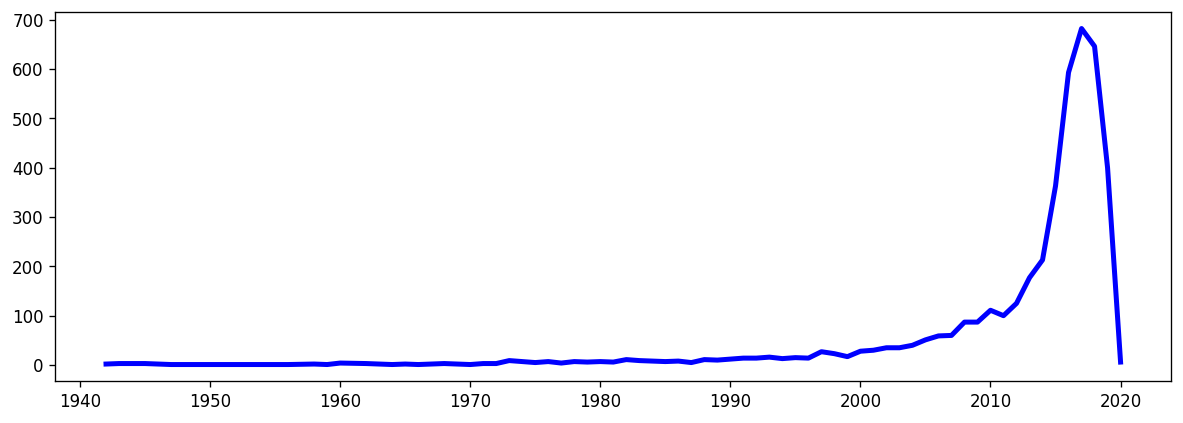

In [37]:
plt.figure(figsize=(12, 4), dpi=120)  # (Width, Height)
plt.plot(
    df.value_counts("release_year").sort_index(),
    color="b",
    # linestyle=":",
    linewidth=3,
    # alpha=0.5        # от 0 до 1 -- где 0 = прозрачный (не видно); 1 - полностью цветной
)
plt.show()

Рисовать несколько графиков на одном окне

**Хороший график** - тот, при взгляде на который мы можем понять все, что на нем изображено. То есть:
1. Название графика (обычно наверху графика)
2. Названия осей: X, Y
3. Легенда, если графиков несколько (или несоклько категорий)

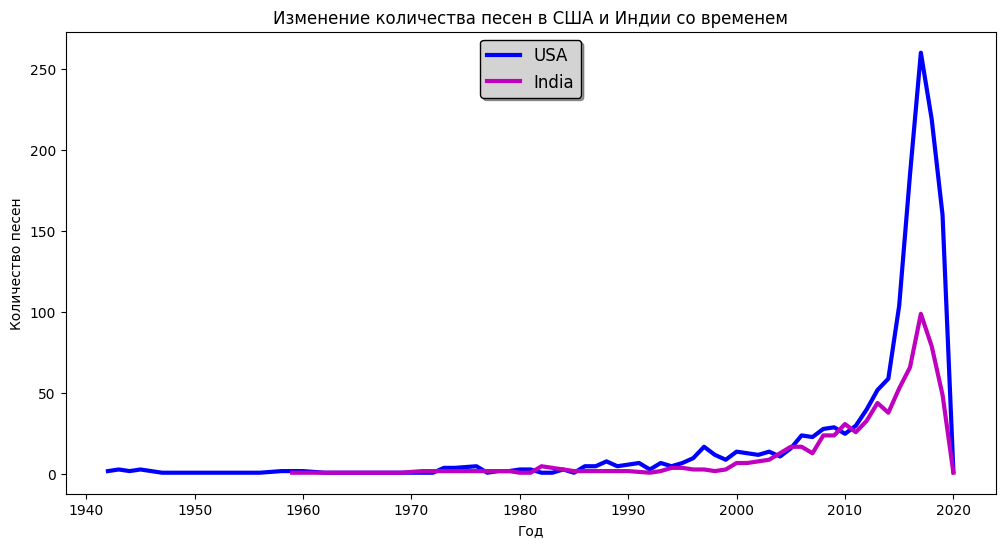

In [40]:
# несколько таймлайнов
# 1. график для US (country = United States)
# 2. график для India (country = India)

us_year_timeline = (
    df[df["country"] == "United States"].value_counts("release_year").sort_index()
)
india_year_timeline = (
    df[df["country"] == "India"].value_counts("release_year").sort_index()
)

## заадем окно
plt.figure(figsize=(12, 6))

## рисуем графики
plt.plot(us_year_timeline, color="b", linewidth=3, label="USA")
plt.plot(india_year_timeline, color="m", linewidth=3, label="India")

## настраиваем все "поверх" -- обертка графика (подписи / легенды ...)
plt.title("Изменение количества песен в США и Индии со временем")
plt.xlabel("Год")
plt.ylabel("Количество песен")

plt.legend(
    loc="upper center",
    frameon=True,
    edgecolor="k",
    facecolor="lightgrey",
    shadow=True,
    fontsize=12,
)
plt.show()

Создание нескольких окон для графиков на одном рисунке

**TASK**
1. Написать функцию, которая по названию страны возвращает временной ряд
2. Нарисовать график `2x3`, где в каждом отдельном окне -- временной ряд по топ-6 странам из `countries_df`. Использовать функцию из п1

In [ ]:
def country(x):
    return df[df["country"] == x].value_counts("release_year").sort_index()

1. получить топ-6 стран по количеству песен (через частотную таблицу - нужны 6 стран с наибольшим числом песен) -> список из 6 стран
2. построить графики = временные ряды для этих 6 стран в одном окне. должно получиться 6 линий (использовать функцию `country()`)

In [103]:
list(df.country.value_counts()[:6].index)

['United States', 'India', 'United Kingdom', 'Canada', 'Spain', 'Turkey']

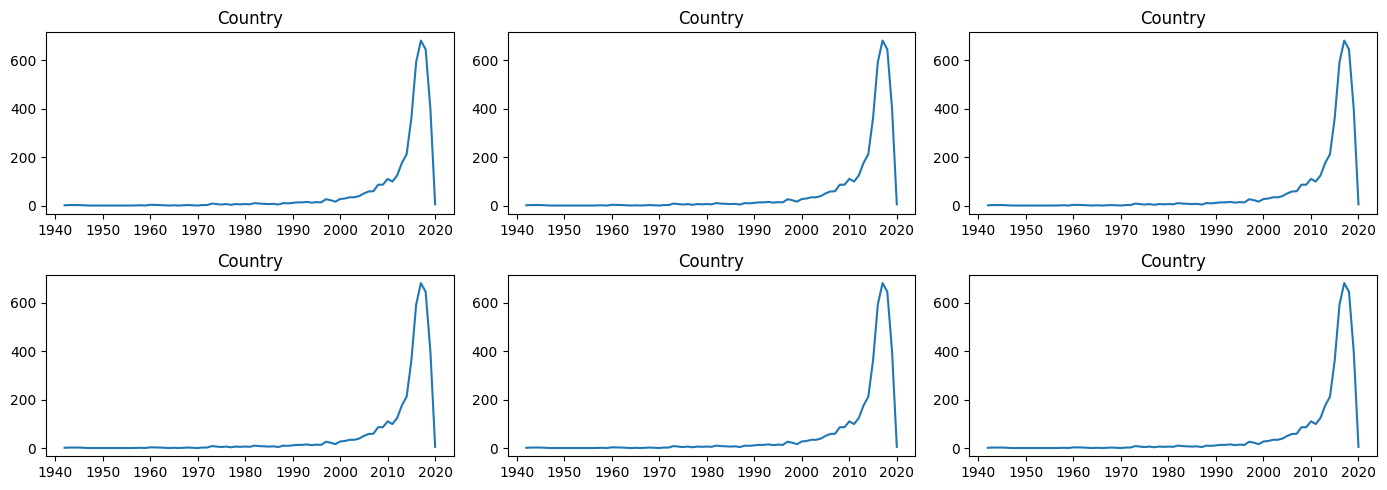

In [ ]:
# количество ячеек = nrows * ncols
# возвращает два объекта: fig - figure; axs - собственно окна итогового графика
# теперь мы будем рисовать не plt.plot(...), а как axs[...].plot(..)

nrows = 2
ncols = 3
fig, axs = plt.subplots(nrows, ncols, figsize=(14, 5))

for row_idx in range(nrows):
    for col_idx in range(ncols):
        ax = axs[row_idx][col_idx]
        ax.plot(df.value_counts("release_year").sort_index())
        ax.set_title("Country")

plt.tight_layout()
plt.show()